In [4]:
import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils import clip_grad_norm_
from tqdm import tqdm

In [16]:
import pandas as pd

df = pd.read_csv("chatbot_emotion_dataset_15000_clean.csv")

print("Total rows:", len(df))
print("\nEmotion distribution:")
print(df['emotion'].value_counts())

Total rows: 15000

Emotion distribution:
emotion
confused      2500
angry         2500
neutral       2500
sad           2500
frustrated    2500
happy         2500
Name: count, dtype: int64


In [17]:
df = df.drop_duplicates()
df = df.dropna()

print("After cleaning:", len(df))
print("\nEmotion distribution:")
print(df['emotion'].value_counts())

After cleaning: 30

Emotion distribution:
emotion
confused      5
angry         5
neutral       5
sad           5
frustrated    5
happy         5
Name: count, dtype: int64


In [18]:
print("Minimum class size:", df['emotion'].value_counts().min())

Minimum class size: 5


# Use go-emotion dataset


In [19]:
!pip install datasets

In [20]:
  from datasets import load_dataset

goemotions = load_dataset("go_emotions")

print(goemotions)
print(goemotions["train"][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})
{'text': "My favourite food is anything I didn't have to cook myself.", 'labels': [27], 'id': 'eebbqej'}


In [21]:
from datasets import load_dataset

goemotions = load_dataset("go_emotions")

print(goemotions)
print(goemotions["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})
{'text': "My favourite food is anything I didn't have to cook myself.", 'labels': [27], 'id': 'eebbqej'}


In [23]:
import pandas as pd

single_label_data = []

for example in goemotions["train"]:
    if len(example["labels"]) == 1:
        single_label_data.append({
            "text": example["text"],
            "label_id": example["labels"][0]
        })

df = pd.DataFrame(single_label_data)

print("Single-label samples:", len(df))

Single-label samples: 36308


In [25]:
label_names = goemotions["train"].features["labels"].feature.names
print(label_names)
df["emotion"] = df["label_id"].apply(lambda x: label_names[x])

print(df["emotion"].value_counts().head(20))

['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']
emotion
neutral           12823
admiration         2710
approval           1873
gratitude          1857
amusement          1652
annoyance          1451
love               1427
disapproval        1402
curiosity          1389
anger              1025
optimism            861
confusion           858
joy                 853
sadness             817
surprise            720
disappointment      709
caring              649
realization         586
excitement          510
disgust             498
Name: count, dtype: int64


In [27]:
keep_emotions = [
    "anger",
    "sadness",
    "joy",
    "neutral",
    "confusion",
    "disappointment"
]

df = df[df["emotion"].isin(keep_emotions)]

print(df["emotion"].value_counts())
df["emotion"] = df["emotion"].replace({
    "joy": "happy",
    "anger": "angry",
    "sadness": "sad",
    "disappointment": "frustrated"
})

print(df["emotion"].value_counts())

emotion
neutral           12823
anger              1025
confusion           858
joy                 853
sadness             817
disappointment      709
Name: count, dtype: int64
emotion
neutral       12823
angry          1025
confusion       858
happy           853
sad             817
frustrated      709
Name: count, dtype: int64


## Train / Val / Test Split (70 / 15 / 15)

In [28]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["emotion"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["emotion"],
    random_state=42
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 11959
Val: 2563
Test: 2563


## Label Encoding

In [37]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train_df["label_enc"] = label_encoder.fit_transform(train_df["emotion"])
val_df["label_enc"] = label_encoder.transform(val_df["emotion"])
test_df["label_enc"] = label_encoder.transform(test_df["emotion"])

num_labels = len(label_encoder.classes_)
print("Emotion classes:", label_encoder.classes_)

Emotion classes: ['angry' 'confusion' 'frustrated' 'happy' 'neutral' 'sad']


## Dataset class

In [38]:
import torch
from torch.utils.data import Dataset

class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

## Initialize Roberta

In [39]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=num_labels
).to(device)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## DataLoaders

In [40]:
train_dataset = EmotionDataset(train_df["text"], train_df["label_enc"], tokenizer)
val_dataset = EmotionDataset(val_df["text"], val_df["label_enc"], tokenizer)
test_dataset = EmotionDataset(test_df["text"], test_df["label_enc"], tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

## Optimizer + Scheduler

In [41]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

optimizer = AdamW(model.parameters(), lr=2e-5)

total_steps = len(train_loader) * 5

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

## Training Loop (With Early Stopping)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [42]:
from torch.nn.utils import clip_grad_norm_
from tqdm import tqdm

best_val_loss = float("inf")
patience = 2
counter = 0

for epoch in range(5):

    model.train()
    train_loss = 0

    for batch in tqdm(train_loader):

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss

        loss.backward()
        clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # 🔹 VALIDATION
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for batch in val_loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    print(f"\nEpoch {epoch+1}")
    print("Train Loss:", avg_train_loss)
    print("Val Loss:", avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), "best_emotion_model.pt")
        print("Best model saved.")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

100%|██████████| 748/748 [02:37<00:00,  4.75it/s]



Epoch 1
Train Loss: 0.7549830163146722
Val Loss: 0.5455624609722854
Best model saved.


100%|██████████| 748/748 [02:36<00:00,  4.76it/s]



Epoch 2
Train Loss: 0.4429475400138666
Val Loss: 0.5265227598572
Best model saved.


100%|██████████| 748/748 [02:36<00:00,  4.77it/s]



Epoch 3
Train Loss: 0.3233694842304377
Val Loss: 0.615934500702142


100%|██████████| 748/748 [02:36<00:00,  4.77it/s]



Epoch 4
Train Loss: 0.22925918623319463
Val Loss: 0.6924400634728141
Early stopping triggered.


## Final text eval


TEST RESULTS
              precision    recall  f1-score   support

       angry       0.55      0.64      0.59       154
   confusion       0.74      0.40      0.52       129
  frustrated       0.48      0.25      0.33       106
       happy       0.76      0.76      0.76       128
     neutral       0.89      0.92      0.90      1924
         sad       0.58      0.63      0.61       122

    accuracy                           0.83      2563
   macro avg       0.67      0.60      0.62      2563
weighted avg       0.82      0.83      0.82      2563



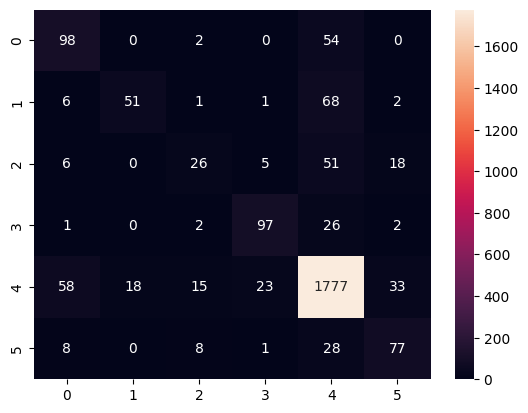

In [43]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.load_state_dict(torch.load("best_emotion_model.pt"))
model.eval()

preds = []
true_labels = []

with torch.no_grad():
    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(outputs.logits, dim=1)

        preds.extend(predictions.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

print("\nTEST RESULTS")
print(classification_report(
    true_labels,
    preds,
    target_names=label_encoder.classes_
))

cm = confusion_matrix(true_labels, preds)
sns.heatmap(cm, annot=True, fmt="d")
plt.show()

## save model

In [44]:
model.save_pretrained("emotion_model")
tokenizer.save_pretrained("emotion_model")
torch.save(label_encoder, "emotion_label_encoder.pt")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
from google.colab import _message
from google.colab import files
import json

# Get notebook JSON
nb = _message.blocking_request('get_ipynb', timeout_sec=5)

# Extract notebook name safely
metadata = nb.get('ipynb', {}).get('metadata', {})
colab_meta = metadata.get('colab', {})

nb_name = colab_meta.get('name', 'downloaded_notebook_emotion.ipynb')

print("Notebook name:", nb_name)

# Save notebook to runtime
with open(nb_name, 'w') as f:
    json.dump(nb['ipynb'], f)

# Download to your computer
files.download(nb_name)